In [3]:
# Usar tensorflow para crear un modelo de red neuronal
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
# Cargar datos preprocesados (PCA aplicado) como DataFrames
train_df = pd.read_csv("../split-dataset/preprocessed/train.csv")
test_df  = pd.read_csv("../split-dataset/preprocessed/test.csv")

# Separar features (X) y target (y)
TARGET = "Bankrupt?"

X_train = train_df.drop(columns=[TARGET]) # Features de entrenamiento
y_train = train_df[TARGET] # Target de entrenamiento

X_test  = test_df.drop(columns=[TARGET]) # Features de test 
y_test  = test_df[TARGET] # Target de test

# Preview
train_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,Bankrupt?
0,1.133671,-0.186087,-0.625234,-6.922642,0.086529,-0.978197,-2.060907,0.374876,3.054031,1.107675,...,1.021925,-0.804689,0.288922,-0.298373,-0.345370,-0.771300,0.737517,-0.621921,-0.056243,0
1,2.242901,5.672264,-3.236105,-1.027564,-0.714721,-3.286395,2.413315,-1.016208,-0.607848,-1.165170,...,-0.994481,0.282730,-1.032156,0.320590,-0.436054,0.056036,0.446762,-0.292237,0.529215,0
2,5.867077,-3.463388,0.165958,-1.009809,1.005097,1.034320,0.953145,0.959746,0.964779,-3.555985,...,1.128002,0.730177,-0.213348,0.413745,-0.235030,-0.102582,0.189199,0.521734,-0.771593,0
3,-0.512040,1.020972,-7.200325,-3.013557,1.485778,-2.180049,3.586174,2.008218,2.431040,0.073241,...,-0.415447,-0.362037,0.823202,-0.235111,1.109341,0.435176,-0.366816,-0.312457,-0.824351,0
4,-1.570264,-14.924489,-0.550775,-1.176489,1.785972,-1.110255,-3.720634,2.267769,-3.578874,-2.994228,...,0.175377,1.143863,2.246699,-0.044279,-0.648572,2.192262,-0.210358,-3.793652,0.192894,0


In [14]:
# X_train, y_train, X_test, y_test ya separados de los CSV preprocesados

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 31 features (PC1..PC31), el numero de dimensiones del dataset
    layers.Dense(64, activation="relu"), # capa oculta 1
    layers.Dense(32, activation="relu"), # capa oculta 2
    layers.Dense(1,  activation="sigmoid"), # salida binaria (Bankrupt? 0/1) usando sigmoid para obtener probabilidades entre 0 y 1
])

model.compile(
    optimizer="adam", # Adam es un optimizador que ajusta el learning rate durante el entrenamiento
    loss="binary_crossentropy", # Binary crossentropy es la función de pérdida adecuada para clasificación binaria
    metrics=["precision", "recall", "auc", "f1_score"] # métricas para evaluar el rendimiento del modelo,
)

history = model.fit(
    X_train, y_train, # entrenar el modelo con los datos de entrenamiento (X_train: features, y_train: etiquetas 0/1)
    validation_split=0.2, # usar el 20% de los datos de entrenamiento para validación durante el entrenamiento
    epochs=100, # número de épocas (iteraciones completas sobre el dataset de entrenamiento)
    batch_size=32, # número de muestras por lote para actualizar los pesos del modelo
    class_weight={0: 1.0, 1: 10.0}, # asignar un peso mayor a la clase minoritaria (Bankrupt? = 1) para compensar el desbalance de clases
)

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - auc: 0.8909 - f1_score: 0.0630 - loss: 0.4555 - precision: 0.2036 - recall: 0.6408 - val_auc: 0.8994 - val_f1_score: 0.0604 - val_loss: 0.2201 - val_precision: 0.2054 - val_recall: 0.6765
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9400 - f1_score: 0.0630 - loss: 0.3493 - precision: 0.2489 - recall: 0.7746 - val_auc: 0.9005 - val_f1_score: 0.0604 - val_loss: 0.1743 - val_precision: 0.2529 - val_recall: 0.6471
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.9516 - f1_score: 0.0630 - loss: 0.3130 - precision: 0.2804 - recall: 0.7958 - val_auc: 0.9019 - val_f1_score: 0.0604 - val_loss: 0.1676 - val_precision: 0.2821 - val_recall: 0.6471
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9621 - f1_score: 0.0630 - loss: 0.2828 - precision: 0.2943 - recall: 0.7958 - val_auc: 0.9087 - val_f1_score: 0.0604 - val_loss: 0.1889 - val_precision: 0.2150 - val_recall: 0.6765
Epoch 5/100
137/137 ━━━━━━━


Matriz de confusión:
[[1304   16]
 [  30   14]]
True Negatives  (TN): 1304
False Positives (FP): 16
False Negatives (FN): 30   ← quiebras no detectadas
True Positives  (TP): 14   ← quiebras detectadas

Reporte por clase:
                precision    recall  f1-score   support

No quiebra (0)      0.978     0.988     0.983      1320
   Quiebra (1)      0.467     0.318     0.378        44

      accuracy                          0.966      1364
     macro avg      0.722     0.653     0.681      1364
  weighted avg      0.961     0.966     0.963      1364



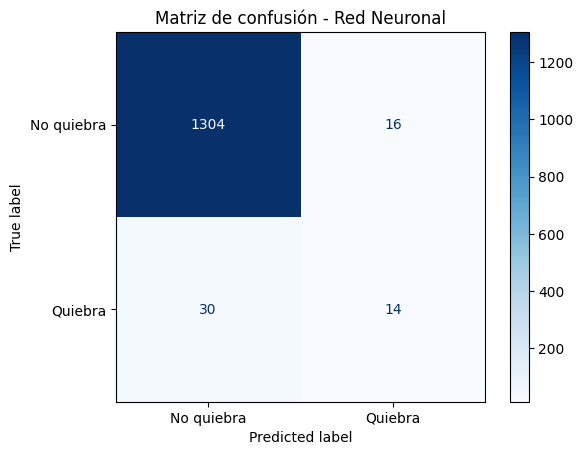

In [16]:
# Predicciones: sigmoid devuelve probabilidades
y_proba = model.predict(X_test, verbose=0).ravel() # Obtener probabilidades de la clase positiva (Bankrupt? = 1) para cada muestra del conjunto de test
y_pred  = (y_proba >= 0.5).astype(int) # Convertir probabilidades a etiquetas binarias usando un umbral de 0.5 (>=0.5 → 1, <0.5 → 0)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred) # Calcular la matriz de confusión comparando las etiquetas reales (y_test) con las predichas (y_pred)
tn, fp, fn, tp = cm.ravel() # Desempaquetar la matriz de confusión en sus componentes: True Negatives (TN), False Positives (FP), False Negatives (FN), True Positives (TP)

print("\nMatriz de confusión:")
print(cm)
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}   ← quiebras no detectadas")
print(f"True Positives  (TP): {tp}   ← quiebras detectadas")

# Reporte por clase (precision, recall, F1)
print("\nReporte por clase:")
print(classification_report(
    y_test, y_pred,
    target_names=["No quiebra (0)", "Quiebra (1)"],
    digits=3,
))

# Visualización
ConfusionMatrixDisplay(cm, display_labels=["No quiebra", "Quiebra"]).plot(
    cmap="Blues", values_format="d"
)
plt.title("Matriz de confusión - Red Neuronal")
plt.show()